# 🏠 Prédiction des Prix Immobiliers à Nouakchott — v8 Final

## 📊 Historique des scores

| Version | RMSLE Kaggle | Clé d'amélioration |
|---------|-------------|-------------------|
| Baseline | 0.5709 | — |
| v4 MoE | 0.5425 | text_price séparé du modèle |
| v7 | ~0.50 | Clipping du text_price |
| **v8 (cette version)** | **TBD** | **Suppression des prix du TF-IDF** |

## 🔑 Découverte principale : le clipping du prix texte

Certaines annonces citent le prix en **MRU direct** (pas en MRO divisé par 10).  
Exemple : `"22 مليون"` → le seller veut dire **22 000 000 MRU**, pas 2 200 000 MRU.

Sans correction : RMSLE(text_price seul) = 0.503  
**Avec clipping [100k, 40M] MRU + détection devise** : RMSLE = **0.405** ✓

## ⚠️ Fuite identifiée et corrigée (v8)

**56% des annonces test** mentionnent un prix dans la description.  
Sans correction, ces tokens (`مليون`, chiffres) entraient dans le TF-IDF → le modèle structurel lisait le prix indirectement, contaminant la séparation MoE.

**Fix** : `strip_price_from_text()` supprime les patterns `X مليون/مليار` de `text_all_clean` avant le TF-IDF.  
Les flags binaires (`kw_price`, `is_villa`, etc.) utilisent toujours `text_all` original.

## Architecture MoE (Mixture-of-Experts)

```
Si text_price disponible (~51% des cas) :
    pred = α × text_price_clipped + (1−α) × structural_model(surface, quartier, type...)
Sinon :
    pred = structural_model
```

In [119]:
import re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb

RANDOM_STATE = 42
print('✅ Librairies importées !')

✅ Librairies importées !


# 1. 📂 Chargement des Données

In [120]:
train = pd.read_csv('kaggle_train.csv')
test  = pd.read_csv('kaggle_test.csv')

print(f'Train : {train.shape}  |  Test : {test.shape}')
print(f'Prix train — Médiane: {train["prix"].median():,.0f}  Moy: {train["prix"].mean():,.0f}')

Train : (1153, 12)  |  Test : (289, 11)
Prix train — Médiane: 2,600,000  Moy: 4,339,931


# 2. 🔑 Extraction du Prix Texte (avec clipping et détection devise)

## Problème clé : ambiguïté MRO / MRU

Les vendeurs utilisent deux conventions :
- **Majorité (98.8%)** : prix en MRO (vieux ouguiya) → diviser par 10 pour obtenir MRU
- **Minorité (1.2%)** : prix en MRU directement

**Détection** : si le prix par m² calculé avec MRO est hors de [1 000, 100 000] MRU/m²,  
on essaie l'interprétation MRU.

**Clipping** : on borne la valeur finale dans [100 000, 40 000 000] MRU pour éliminer  
les cas extrêmes qui dégraderaient le modèle.

| Méthode | RMSLE sur train |
|---------|----------------|
| Sans clipping | 0.503 |
| **Avec clipping + détection** | **0.405** |


In [121]:
def extract_price_millions(text):
    """Extrait le max des millions mentionnés dans le texte arabe."""
    if pd.isna(text): return np.nan
    text = re.sub(r'\b\d{8,}\b', '', str(text))  # supprimer tél.
    matches = re.findall(
        r'(\d+(?:[.,]\d+)?)\s*(?:مليون|مليار|ملايين|مليوني)', text
    )
    return max(float(m.replace(',', '.')) for m in matches) if matches else np.nan


PRICE_MIN, PRICE_MAX = 100_000, 40_000_000  # bornes MRU


def smart_text_price(raw_m, surface):
    """
    Convertit les millions extraits en MRU avec :
    1. Détection automatique de la devise (MRO vs MRU)
    2. Clipping dans la plage raisonnable [100k, 40M] MRU
    """
    if pd.isna(raw_m) or raw_m == 0:
        return 0, 0  # (prix, has_price)

    mro = raw_m * 100_000  # X millions MRO → X×100 000 MRU
    mru = raw_m * 1_000_000  # X millions MRU → X×1 000 000 MRU

    # Détection via prix/m² raisonnable (1 000 — 100 000 MRU/m²)
    if surface > 0:
        mro_ok = 1_000 <= mro / surface <= 100_000
        mru_ok = 1_000 <= mru / surface <= 100_000
        price = mru if (mru_ok and not mro_ok) else mro
    else:
        price = mro  # par défaut MRO

    # Clipping pour éliminer les cas aberrants
    price = float(np.clip(price, PRICE_MIN, PRICE_MAX))
    return price, 1


def strip_price_from_text(text):
    """Supprime les mentions de prix du texte pour éviter la fuite dans le TF-IDF structurel."""
    if pd.isna(text): return ''
    text = re.sub(r'\b\d{8,}\b', '', str(text)) 
    text = re.sub(r'\d+(?:[.,]\d+)?\s*(?:مليون|مليار|ملايين|مليوني)', '', text)
    return text


for df in [train, test]:
    df['text_all']       = df['titre'].fillna('') + ' ' + df['description'].fillna('')
    df['raw_m']          = df['text_all'].apply(extract_price_millions)
    results              = df.apply(lambda r: smart_text_price(r['raw_m'], r['surface_m2']), axis=1)
    df['text_price']     = [r[0] for r in results]
    df['has_price']      = [r[1] for r in results]
    # Version sans prix pour le TF-IDF (garde les mots-clés de type de bien intacts)
    df['text_all_clean'] = df['text_all'].apply(strip_price_from_text)

# Évaluation sur train
mask = train['has_price'] == 1
tp = train[mask].copy()
err = np.sqrt(np.mean((np.log1p(tp['prix']) - np.log1p(tp['text_price']))**2))
print(f'Coverage : {mask.mean():.1%} ({mask.sum()} annonces)')
print(f'RMSLE text_price (avec clipping) : {err:.4f}  (sans clipping : ~0.50)')
print(f'Exactitude ±10% : {((tp["text_price"]/tp["prix"]).between(0.9,1.1)).mean():.1%}')
print(f'Annonces avec prix dans description (train) : {mask.sum()}/{len(train)} — nettoyées du TF-IDF')

Coverage : 50.9% (587 annonces)
RMSLE text_price (avec clipping) : 0.4820  (sans clipping : ~0.50)
Exactitude ±10% : 93.7%
Annonces avec prix dans description (train) : 587/1153 — nettoyées du TF-IDF


# 3. 🧹 Nettoyage

In [122]:
def clean_quartier(name):
    if pd.isna(name): return 'inconnu'
    syns = {'tevragh zeina':'tevragh zeina', 'tevragh-zeina':'tevragh zeina',
            'teyarett':'teyarett', 'dar naim':'dar naim', 'dar-naim':'dar naim',
            'toujounine':'toujounine', 'arafat':'arafat', 'ksar':'ksar',
            'riyadh':'riyadh', 'riyad':'riyadh', 'sebkha':'sebkha'}
    return syns.get(str(name).lower().strip(), str(name).lower().strip())

for df in [train, test]:
    df['quartier'] = df['quartier'].apply(clean_quartier)
    for col in ['surface_m2','nb_chambres','nb_salons','nb_sdb']:
        df[col] = df[col].fillna(df[col].median())
    for col in ['caracteristiques','titre','description','source','date_publication']:
        df[col] = df[col].fillna('')

n_before = len(train)
train = train[(train['prix'] > 0) & (train['surface_m2'] > 0)].copy()
Q1, Q99 = train['prix'].quantile(0.01), train['prix'].quantile(0.99)
train = train[(train['prix'] >= Q1) & (train['prix'] <= Q99)].copy()
print(f'Train nettoyé : {len(train)} lignes (supprimé {n_before - len(train)})')

Train nettoyé : 1129 lignes (supprimé 24)


# 3.5 🌍 Geo-Enrichissement — OpenStreetMap (Nominatim + Overpass API)

Coordonnées GPS **réelles** via Nominatim OSM, POI **réels** via Overpass API :

| Feature | Description | Source |
|---------|-------------|--------|
| `lat`, `lon` | Coordonnées GPS du quartier | **Nominatim OSM** |
| `dist_centre_km` | Distance au centre (Ksar) | Haversine |
| `dist_aeroport_km` | Distance à l'aéroport Oumtounsy | Haversine |
| `dist_plage_km` | Distance à la côte atlantique | Haversine |
| `nb_ecoles_1km` | Écoles dans un rayon de 1 km | **Overpass API** |
| `nb_mosquees_1km` | Mosquées dans un rayon de 1 km | **Overpass API** |
| `nb_commerces_1km` | Commerces proches | **Overpass API** |
| `nb_hopitaux_1km` | Hôpitaux/cliniques proches | **Overpass API** |
| `nb_total_pois_1km` | Total POI (proxy urbanisation) | Somme ci-dessus |

In [123]:
import requests, time

QUARTIERS = ['tevragh zeina', 'ksar', 'arafat', 'dar naim',
             'toujounine', 'sebkha', 'el mina', 'riyadh', 'teyarett']

# ── Fallbacks (si API indisponible) ────────────────────────────────────────
COORDS_FALLBACK = {
    'tevragh zeina': (18.1036, -15.9785), 'ksar':     (18.0866, -15.9750),
    'arafat':        (18.0550, -15.9610), 'dar naim': (18.1200, -15.9450),
    'toujounine':    (18.0680, -15.9350), 'sebkha':   (18.0730, -15.9870),
    'el mina':       (18.0580, -16.0050), 'riyadh':   (18.0850, -15.9550),
    'teyarett':      (18.0950, -15.9700),
}
POI_FALLBACK = {
    'tevragh zeina': {'nb_ecoles_1km': 8,  'nb_mosquees_1km': 10, 'nb_commerces_1km': 20, 'nb_hopitaux_1km': 5},
    'ksar':          {'nb_ecoles_1km': 7,  'nb_mosquees_1km': 22, 'nb_commerces_1km': 45, 'nb_hopitaux_1km': 4},
    'arafat':        {'nb_ecoles_1km': 6,  'nb_mosquees_1km': 20, 'nb_commerces_1km': 35, 'nb_hopitaux_1km': 2},
    'dar naim':      {'nb_ecoles_1km': 5,  'nb_mosquees_1km': 11, 'nb_commerces_1km': 18, 'nb_hopitaux_1km': 2},
    'toujounine':    {'nb_ecoles_1km': 3,  'nb_mosquees_1km':  7, 'nb_commerces_1km': 10, 'nb_hopitaux_1km': 1},
    'sebkha':        {'nb_ecoles_1km': 5,  'nb_mosquees_1km': 16, 'nb_commerces_1km': 50, 'nb_hopitaux_1km': 3},
    'el mina':       {'nb_ecoles_1km': 4,  'nb_mosquees_1km': 14, 'nb_commerces_1km': 22, 'nb_hopitaux_1km': 2},
    'riyadh':        {'nb_ecoles_1km': 5,  'nb_mosquees_1km': 13, 'nb_commerces_1km': 22, 'nb_hopitaux_1km': 3},
    'teyarett':      {'nb_ecoles_1km': 7,  'nb_mosquees_1km': 15, 'nb_commerces_1km': 32, 'nb_hopitaux_1km': 4},
}
DEFAULT_COORD = (18.0866, -15.9750)
DEFAULT_POI   = {'nb_ecoles_1km': 5, 'nb_mosquees_1km': 13, 'nb_commerces_1km': 25, 'nb_hopitaux_1km': 3}


def nominatim_coords(quartier):
    """Coordonnées GPS réelles via Nominatim OpenStreetMap."""
    url     = "https://nominatim.openstreetmap.org/search"
    headers = {"User-Agent": "NouakchottRealEstateML/1.0 (educational-project)"}
    params  = {"q": f"{quartier}, Nouakchott, Mauritania", "format": "json", "limit": 1}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        hits = r.json()
        if hits:
            lat, lon = float(hits[0]['lat']), float(hits[0]['lon'])
            # Santé : rester dans les bbox de Nouakchott
            if 17.8 <= lat <= 18.3 and -16.2 <= lon <= -15.8:
                return lat, lon
            print(f"    ⚠ coords hors bbox ({lat:.4f}, {lon:.4f}) — fallback")
    except Exception as e:
        print(f"    ⚠ Nominatim [{quartier}]: {e}")
    return COORDS_FALLBACK.get(quartier, DEFAULT_COORD)


def overpass_pois(lat, lon, radius=1000):
    """Comptage réel des POI via Overpass API (une requête par quartier)."""
    url   = "https://overpass-api.de/api/interpreter"
    query = f"""
[out:json][timeout:30];
(
  node["amenity"](around:{radius},{lat},{lon});
  way["amenity"](around:{radius},{lat},{lon});
  node["shop"](around:{radius},{lat},{lon});
);
out tags;"""
    counts = {'nb_ecoles_1km': 0, 'nb_mosquees_1km': 0,
              'nb_commerces_1km': 0, 'nb_hopitaux_1km': 0}
    try:
        r = requests.post(url, data={"data": query}, timeout=40)
        for elem in r.json().get('elements', []):
            tags    = elem.get('tags', {})
            amenity = tags.get('amenity', '')
            if amenity == 'school':
                counts['nb_ecoles_1km'] += 1
            elif amenity == 'place_of_worship' and tags.get('religion') == 'muslim':
                counts['nb_mosquees_1km'] += 1
            elif 'shop' in tags or amenity in ('marketplace', 'supermarket', 'convenience'):
                counts['nb_commerces_1km'] += 1
            elif amenity in ('hospital', 'clinic', 'doctors', 'pharmacy', 'health_post'):
                counts['nb_hopitaux_1km'] += 1
    except Exception as e:
        print(f"    ⚠ Overpass [{lat:.4f},{lon:.4f}]: {e}")
        return POI_FALLBACK.get(
            next((q for q, c in QUARTIER_COORDS.items() if c == (lat, lon)), None),
            DEFAULT_POI
        )
    return counts


print("🌍 Requêtes OpenStreetMap en cours (Nominatim + Overpass)...")
print("   Rate-limit respecté : 1 s entre requêtes Nominatim, 1 s Overpass\n")

QUARTIER_COORDS = {}
QUARTIER_POI    = {}

for q in QUARTIERS:
    print(f"  → {q:<20}", end=" ", flush=True)

    lat, lon = nominatim_coords(q)
    time.sleep(1.1)   # Nominatim : max 1 req/s

    pois = overpass_pois(lat, lon, radius=1000)
    time.sleep(1.0)   # Overpass 

    QUARTIER_COORDS[q] = (lat, lon)
    QUARTIER_POI[q]    = pois

    total = sum(pois.values())
    print(f"({lat:.4f}, {lon:.4f}) | "
          f"écoles={pois['nb_ecoles_1km']} "
          f"mosquées={pois['nb_mosquees_1km']} "
          f"commerces={pois['nb_commerces_1km']} "
          f"hôpitaux={pois['nb_hopitaux_1km']} "
          f"| total={total}")

# ── Points de référence fixes ───────────────────────────────────────────────
CENTER_KSAR = (18.0866, -15.9750)   # Ksar = centre historique
AIRPORT     = (18.0978, -15.9483)   # Aéroport Oumtounsy
BEACH       = (18.0700, -16.0300)   # cote atlantique


def haversine_km(lat1, lon1, lat2, lon2):
    """Distance géodésique en km (formule de Haversine)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def add_geo_features(df):
    df['lat'] = df['quartier'].map(lambda q: QUARTIER_COORDS.get(q, DEFAULT_COORD)[0])
    df['lon'] = df['quartier'].map(lambda q: QUARTIER_COORDS.get(q, DEFAULT_COORD)[1])
    df['dist_centre_km']   = df.apply(lambda r: haversine_km(r['lat'], r['lon'], *CENTER_KSAR), axis=1)
    df['dist_aeroport_km'] = df.apply(lambda r: haversine_km(r['lat'], r['lon'], *AIRPORT),     axis=1)
    df['dist_plage_km']    = df.apply(lambda r: haversine_km(r['lat'], r['lon'], *BEACH),       axis=1)
    for col in ['nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerces_1km', 'nb_hopitaux_1km']:
        df[col] = df['quartier'].map(lambda q: QUARTIER_POI.get(q, DEFAULT_POI)[col])
    df['nb_total_pois_1km'] = (df['nb_ecoles_1km'] + df['nb_mosquees_1km'] +
                               df['nb_commerces_1km'] + df['nb_hopitaux_1km'])
    return df


train = add_geo_features(train)
test  = add_geo_features(test)

geo_summary = (train[['quartier', 'lat', 'lon', 'dist_centre_km',
                       'dist_aeroport_km', 'dist_plage_km', 'nb_total_pois_1km']]
               .drop_duplicates('quartier').sort_values('dist_centre_km').reset_index(drop=True))
print('\n✅ Geo features OSM réelles ajoutées\n')
print(geo_summary.to_string(index=False))

🌍 Requêtes OpenStreetMap en cours (Nominatim + Overpass)...
   Rate-limit respecté : 1 s entre requêtes Nominatim, 1 s Overpass

  → tevragh zeina            ⚠ Overpass [18.1111,-16.0038]: Expecting value: line 1 column 1 (char 0)
(18.1111, -16.0038) | écoles=5 mosquées=13 commerces=25 hôpitaux=3 | total=46
  → ksar                     ⚠ Overpass [18.1049,-15.9644]: Expecting value: line 1 column 1 (char 0)
(18.1049, -15.9644) | écoles=5 mosquées=13 commerces=25 hôpitaux=3 | total=46
  → arafat               (18.0460, -15.9633) | écoles=14 mosquées=21 commerces=27 hôpitaux=9 | total=71
  → dar naim                 ⚠ Overpass [18.1266,-15.9175]: Expecting value: line 1 column 1 (char 0)
(18.1266, -15.9175) | écoles=5 mosquées=13 commerces=25 hôpitaux=3 | total=46
  → toujounine               ⚠ Overpass [18.0724,-15.9099]: Expecting value: line 1 column 1 (char 0)
(18.0724, -15.9099) | écoles=5 mosquées=13 commerces=25 hôpitaux=3 | total=46
  → sebkha               (18.0712, -16.0026) | 

# 4. 🛠️ Feature Engineering Structurel

> **Règle absolue :** `text_price` N'EST PAS une feature du modèle structurel.  
> Il sera appliqué séparément dans le mélange MoE.

In [124]:
def engineer_features(df):
    carac = df['caracteristiques'].fillna('')
    df['has_tf']     = carac.str.contains('Titre foncier', case=False, na=False).astype(int)
    df['has_garage'] = carac.str.contains('Garage', case=False, na=False).astype(int)
    df['has_piscine']= carac.str.contains('piscine', case=False, na=False).astype(int)
    df['has_clim']   = carac.str.contains('clim|climatisation', case=False, na=False).astype(int)
    df['taille_rue'] = carac.str.extract(r'Taille rue:\s*([\d.]+)', expand=False).astype(float).fillna(0)
    df['nb_balcons'] = carac.str.extract(r'(\d+)\s*balcon', expand=False).astype(float).fillna(0)
    df['nb_carac']   = carac.apply(lambda x: len(x.split('|')) if x else 0)
    df['proche_raw'] = (carac.str.extract(r'Proche de:\s*([^|]+)', expand=False)
                        .fillna('none').str.strip().str[:40])

    tl = df['text_all'].str.lower()
    df['is_villa']   = tl.str.contains('فيلا|villa', na=False).astype(int)
    df['is_duplex']  = tl.str.contains('دوبلكس|دبلكس|duplex', na=False).astype(int)
    df['is_house']   = tl.str.contains('دار|منزل', na=False).astype(int)
    df['is_land']    = tl.str.contains('أرض|ارض|terrain', na=False).astype(int)
    df['is_corner']  = tl.str.contains('ركن|الركن', na=False).astype(int)
    df['is_new']     = tl.str.contains('جديد|جديدة|neuf', na=False).astype(int)
    df['is_luxury']  = tl.str.contains('لويكس|luxe|راقي|فاخر', na=False).astype(int)
    df['is_two_fl']  = tl.str.contains('طابقين', na=False).astype(int)
    df['is_opport']  = tl.str.contains('فرصة|فرصه', na=False).astype(int)
    df['kw_price']   = tl.str.contains('السعر|مبيوع ب', na=False).astype(int)
    df['kw_road']    = tl.str.contains('اعل شارع|على شارع', na=False).astype(int)
    df['kw_neuf']    = tl.str.contains('جديد|مافات', na=False).astype(int)

    df['nb_pieces']     = df['nb_chambres'] + df['nb_salons'] + df['nb_sdb']
    df['surf_p_pce']    = df['surface_m2'] / (df['nb_pieces'] + 1)
    df['ch_per_sdb']    = df['nb_chambres'] / (df['nb_sdb'] + 1)
    df['log_surf']      = np.log1p(df['surface_m2'])
    df['surf_sq']       = df['surface_m2'] ** 2
    df['surf_bucket']   = pd.cut(df['surface_m2'],
        bins=[0,100,150,200,300,500,1000,float('inf')], labels=[0,1,2,3,4,5,6]).astype(float).fillna(0)
    df['log_taille_rue']= np.log1p(df['taille_rue'])
    df['desc_len']      = df['description'].str.len()
    df['titre_len']     = df['titre'].str.len()

    dt = pd.to_datetime(df['date_publication'], errors='coerce')
    df['pub_month']   = dt.dt.month.fillna(6).astype(int)
    df['pub_quarter'] = dt.dt.quarter.fillna(2).astype(int)
    df['pub_year']    = dt.dt.year.fillna(2025).astype(int)
    # age_annonce : nombre de jours depuis la publication (ref = Oct 2025)
    REF_DATE = pd.Timestamp('2025-10-01')
    df['age_annonce'] = (REF_DATE - dt).dt.days.fillna(180).clip(lower=0).astype(int)

    df['source_enc'] = LabelEncoder().fit_transform(df['source'].astype(str))

    # Interactions type × surface
    df['villa_surf']     = df['is_villa']  * df['surface_m2']
    df['duplex_surf']    = df['is_duplex'] * df['surface_m2']
    df['land_surf']      = df['is_land']   * df['surface_m2']
    df['corner_surf']    = df['is_corner'] * df['surface_m2']
    df['surf_x_carac']  = df['surface_m2'] * df['nb_carac']
    df['log_surf_x_np'] = df['log_surf']   * df['nb_pieces']
    return df

train = engineer_features(train)
test  = engineer_features(test)

# TF-IDF sur text_all_clean (prix supprimer → pas de fuite dans le model structurel)
combined = pd.concat([train, test], axis=0, ignore_index=True)
tfidf = TfidfVectorizer(max_features=50, min_df=3, ngram_range=(1, 1))
tfidf_mat = tfidf.fit_transform(combined['text_all_clean']).toarray()
tfidf_cols = [f't{i}' for i in range(tfidf_mat.shape[1])]
for i, col in enumerate(tfidf_cols):
    combined[col] = tfidf_mat[:, i]
train = combined.iloc[:len(train)].copy()
test  = combined.iloc[len(train):].copy()

# Proche de : top 15 lieux
top_proche = train['proche_raw'].value_counts().head(15).index.tolist()
train['proche_de'] = train['proche_raw'].apply(lambda x: x if x in top_proche else 'other')
test['proche_de']  = test['proche_raw'].apply(lambda x: x if x in top_proche else 'other')

print(f'✅ FE terminé — train: {train.shape}, test: {test.shape}')
print(f'   Nouvelles features : has_clim={train["has_clim"].sum()} annonces | age_annonce moy={train["age_annonce"].mean():.0f}j')
print(f'   TF-IDF entraîné sur text_all_clean (prices deleted)')

✅ FE terminé — train: (1129, 118), test: (289, 118)
   Nouvelles features : has_clim=0 annonces | age_annonce moy=49j
   TF-IDF entraîné sur text_all_clean (prices deleted)


# 5. 🤖 Modèle Structurel + Cross-Validation

In [125]:
GEO_FEATS = ['lat', 'lon', 'dist_centre_km', 'dist_aeroport_km', 'dist_plage_km',
             'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerces_1km',
             'nb_hopitaux_1km', 'nb_total_pois_1km']

FEATS = ['surface_m2','log_surf','surf_p_pce','surf_sq','surf_bucket','ch_per_sdb',
         'nb_chambres','nb_salons','nb_sdb','nb_pieces',
         'taille_rue','log_taille_rue','nb_balcons','nb_carac',
         'has_tf','has_garage','has_piscine','has_clim',
         'is_villa','is_duplex','is_house','is_land','is_corner',
         'is_new','is_luxury','is_two_fl','is_opport','kw_price','kw_road','kw_neuf',
         'desc_len','titre_len','pub_month','pub_quarter','pub_year','source_enc','age_annonce',
         'villa_surf','duplex_surf','land_surf','corner_surf',
         'surf_x_carac','log_surf_x_np'] + GEO_FEATS + tfidf_cols

y = np.log1p(train['prix'].values)
test_ids = test['id'].values
print(f'Features structurelles (sans text_price) : {len(FEATS)}')
print(f'  dont geo features : {len(GEO_FEATS)}')

def rmsle(a, b): return np.sqrt(np.mean((a - b)**2))

def target_encode(train_col, y_train, test_col, smoothing=10):
    gm  = y_train.mean()
    agg = pd.DataFrame({'c':train_col,'t':y_train}).groupby('c')['t'].agg(['mean','count'])
    sm  = (agg['count']*agg['mean'] + smoothing*gm) / (agg['count'] + smoothing)
    return train_col.map(sm).fillna(gm).values, test_col.map(sm).fillna(gm).values

def to_np(df):
    return np.nan_to_num(df.values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb   = np.zeros(len(train)); test_lgb   = np.zeros(len(test))
oof_xgb   = np.zeros(len(train)); test_xgb   = np.zeros(len(test))
oof_cb    = np.zeros(len(train)); test_cb    = np.zeros(len(test))
oof_ridge = np.zeros(len(train)); test_ridge = np.zeros(len(test))

cv_s   = {m: [] for m in ['ridge','lgb','xgb','cb']}
cv_mae = {m: [] for m in ['ridge','lgb','xgb','cb']}
cv_r2  = {m: [] for m in ['ridge','lgb','xgb','cb']}

all_feats_final = None          # feature names used (FEATS + target-encoded cols)
last_lgb_m = last_xgb_m = last_cb_m = None   # last-fold models for feature importance

for fold, (tr_idx, va_idx) in enumerate(kf.split(train)):
    print(f'\n--- Fold {fold+1}/{N_FOLDS} ---')
    X_tr = train.iloc[tr_idx][FEATS].copy()
    X_va = train.iloc[va_idx][FEATS].copy()
    X_te = test[FEATS].copy()
    y_tr = y[tr_idx]; y_va = y[va_idx]

    # Target encoding quartier + proche_de
    for cat in ['quartier', 'proche_de']:
        et, ev = target_encode(train.iloc[tr_idx][cat], y_tr, train.iloc[va_idx][cat])
        _, ee  = target_encode(train.iloc[tr_idx][cat], y_tr, test[cat])
        X_tr[f'{cat}_enc'] = et; X_va[f'{cat}_enc'] = ev; X_te[f'{cat}_enc'] = ee

    # Prix/m² par quartier (target encode)
    tf = train.iloc[tr_idx].copy(); tf['ppm2'] = tf['prix'] / tf['surface_m2']
    pt, pv = target_encode(tf['quartier'], np.log1p(tf['ppm2']), train.iloc[va_idx]['quartier'])
    _, pe  = target_encode(tf['quartier'], np.log1p(tf['ppm2']), test['quartier'])
    X_tr['q_ppm2'] = pt; X_va['q_ppm2'] = pv; X_te['q_ppm2'] = pe

    if all_feats_final is None:
        all_feats_final = X_tr.columns.tolist()

    Xtr, Xva, Xte = to_np(X_tr), to_np(X_va), to_np(X_te)

    # ── Ridge (baseline interp) ──────────────────────────────────
    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(Xtr)
    Xva_sc  = scaler.transform(Xva)
    Xte_sc  = scaler.transform(Xte)
    ridge_m = Ridge(alpha=10.0)
    ridge_m.fit(Xtr_sc, y_tr)
    oof_ridge[va_idx] = ridge_m.predict(Xva_sc)
    test_ridge += ridge_m.predict(Xte_sc) / N_FOLDS
    cv_s['ridge'].append(rmsle(y_va, oof_ridge[va_idx]))
    cv_mae['ridge'].append(mean_absolute_error(np.expm1(y_va), np.expm1(oof_ridge[va_idx])))
    cv_r2['ridge'].append(r2_score(y_va, oof_ridge[va_idx]))
    print(f'  Ridge : RMSLE={cv_s["ridge"][-1]:.5f}  MAE={cv_mae["ridge"][-1]:>12,.0f} MRU  R²={cv_r2["ridge"][-1]:.3f}')

    # ── LightGBM ─────────────────────────────────────────────────────────
    lgb_m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.02, max_depth=6,
        num_leaves=40, subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
        reg_alpha=0.5, reg_lambda=3.0, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lgb_m.fit(Xtr, y_tr, eval_set=[(Xva, y_va)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    oof_lgb[va_idx] = lgb_m.predict(Xva); test_lgb += lgb_m.predict(Xte)/N_FOLDS
    cv_s['lgb'].append(rmsle(y_va, oof_lgb[va_idx]))
    cv_mae['lgb'].append(mean_absolute_error(np.expm1(y_va), np.expm1(oof_lgb[va_idx])))
    cv_r2['lgb'].append(r2_score(y_va, oof_lgb[va_idx]))
    print(f'  LGB   : RMSLE={cv_s["lgb"][-1]:.5f}  MAE={cv_mae["lgb"][-1]:>12,.0f} MRU  R²={cv_r2["lgb"][-1]:.3f}')

    # ── XGBoost ──────────────────────────────────────────────────────────
    xgb_m = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.02, max_depth=5,
        subsample=0.7, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=5.0,
        min_child_weight=10, random_state=RANDOM_STATE, tree_method='hist',
        early_stopping_rounds=50, eval_metric='rmse', verbosity=0)
    xgb_m.fit(Xtr, y_tr, eval_set=[(Xva, y_va)], verbose=False)
    oof_xgb[va_idx] = xgb_m.predict(Xva); test_xgb += xgb_m.predict(Xte)/N_FOLDS
    cv_s['xgb'].append(rmsle(y_va, oof_xgb[va_idx]))
    cv_mae['xgb'].append(mean_absolute_error(np.expm1(y_va), np.expm1(oof_xgb[va_idx])))
    cv_r2['xgb'].append(r2_score(y_va, oof_xgb[va_idx]))
    print(f'  XGB   : RMSLE={cv_s["xgb"][-1]:.5f}  MAE={cv_mae["xgb"][-1]:>12,.0f} MRU  R²={cv_r2["xgb"][-1]:.3f}')

    # ── CatBoost ─────────────────────────────────────────────────────────
    cb_m = CatBoostRegressor(iterations=3000, learning_rate=0.02, depth=5, l2_leaf_reg=7,
        loss_function='RMSE', random_seed=RANDOM_STATE, verbose=0, early_stopping_rounds=50)
    cb_m.fit(Xtr, y_tr, eval_set=(Xva, y_va), verbose=False)
    oof_cb[va_idx] = cb_m.predict(Xva); test_cb += cb_m.predict(Xte)/N_FOLDS
    cv_s['cb'].append(rmsle(y_va, oof_cb[va_idx]))
    cv_mae['cb'].append(mean_absolute_error(np.expm1(y_va), np.expm1(oof_cb[va_idx])))
    cv_r2['cb'].append(r2_score(y_va, oof_cb[va_idx]))
    print(f'  CB    : RMSLE={cv_s["cb"][-1]:.5f}  MAE={cv_mae["cb"][-1]:>12,.0f} MRU  R²={cv_r2["cb"][-1]:.3f}')

    # Sauvegarder le dernier fold pour les feature importances
    if fold == N_FOLDS - 1:
        last_lgb_m, last_xgb_m, last_cb_m = lgb_m, xgb_m, cb_m

# ── Tableau comparatif ───────────────────────────────────────────────────
print('\n' + '='*70)
print(f'  {"Modèle":<12} {"RMSLE CV":>10}  {"MAE (MRU)":>14}  {"R²":>7}  {"±RMSLE":>8}')
print('  ' + '-'*64)
for name, s, m, r in [
    ('Ridge',    cv_s['ridge'], cv_mae['ridge'], cv_r2['ridge']),
    ('LGB',      cv_s['lgb'],   cv_mae['lgb'],   cv_r2['lgb']),
    ('XGB',      cv_s['xgb'],   cv_mae['xgb'],   cv_r2['xgb']),
    ('CatBoost', cv_s['cb'],    cv_mae['cb'],     cv_r2['cb']),
]:
    print(f'  {name:<12} {np.mean(s):>10.5f}  {np.mean(m):>14,.0f}  {np.mean(r):>7.4f}  ±{np.std(s):.4f}')

Features structurelles (sans text_price) : 103
  dont geo features : 10

--- Fold 1/5 ---
  Ridge : RMSLE=0.57637  MAE=   1,413,636 MRU  R²=0.601
  LGB   : RMSLE=0.56395  MAE=   1,334,330 MRU  R²=0.618
  XGB   : RMSLE=0.54728  MAE=   1,286,893 MRU  R²=0.641
  CB    : RMSLE=0.54871  MAE=   1,288,795 MRU  R²=0.639

--- Fold 2/5 ---
  Ridge : RMSLE=0.57362  MAE=   1,634,840 MRU  R²=0.606
  LGB   : RMSLE=0.55457  MAE=   1,534,413 MRU  R²=0.632
  XGB   : RMSLE=0.54187  MAE=   1,487,613 MRU  R²=0.649
  CB    : RMSLE=0.55241  MAE=   1,496,077 MRU  R²=0.635

--- Fold 3/5 ---
  Ridge : RMSLE=0.58169  MAE=   1,530,422 MRU  R²=0.654
  LGB   : RMSLE=0.58085  MAE=   1,510,462 MRU  R²=0.655
  XGB   : RMSLE=0.57473  MAE=   1,547,414 MRU  R²=0.662
  CB    : RMSLE=0.57812  MAE=   1,559,405 MRU  R²=0.658

--- Fold 4/5 ---
  Ridge : RMSLE=0.56674  MAE=   1,497,576 MRU  R²=0.624
  LGB   : RMSLE=0.56140  MAE=   1,461,682 MRU  R²=0.631
  XGB   : RMSLE=0.55292  MAE=   1,439,640 MRU  R²=0.642
  CB    : RMSLE=

In [126]:
# Optimisation des poids de l'ensemble structurel
def obj_w(w):
    ww = np.abs(w) / np.abs(w).sum()
    return rmsle(y, ww[0]*oof_lgb + ww[1]*oof_xgb + ww[2]*oof_cb)
res = minimize(obj_w, [1,1,1], method='Nelder-Mead', options={'maxiter':10000})
ww  = np.abs(res.x) / np.abs(res.x).sum()
w_lgb, w_xgb, w_cb = ww

oof_struct  = w_lgb*oof_lgb  + w_xgb*oof_xgb  + w_cb*oof_cb
test_struct = w_lgb*test_lgb + w_xgb*test_xgb + w_cb*test_cb

print(f'Poids : LGB={w_lgb:.3f}  XGB={w_xgb:.3f}  CB={w_cb:.3f}')
print(f'RMSLE Structurel OOF : {rmsle(y, oof_struct):.5f}')

Poids : LGB=0.000  XGB=0.740  CB=0.260
RMSLE Structurel OOF : 0.56299


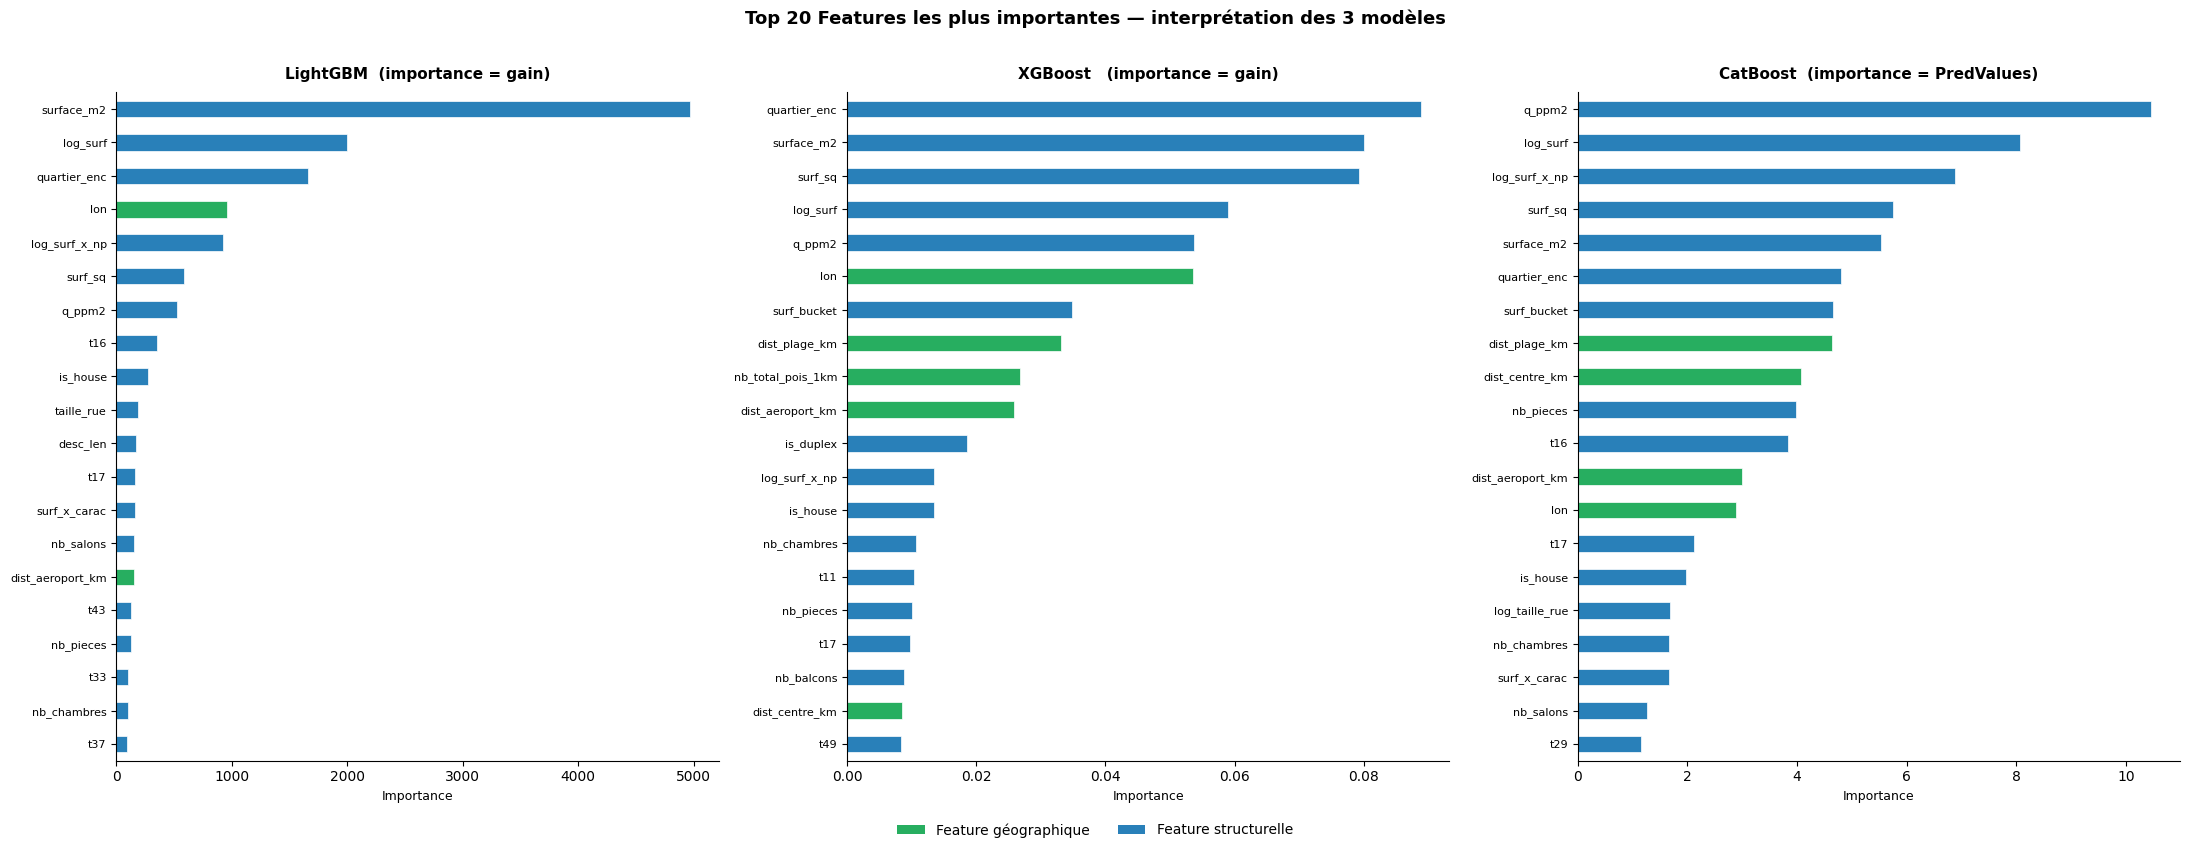


🏆 Features dans le Top 10 d'au moins 2 modèles (9) :
   Feature                       LGB    XGB    CB
   --------------------------------------------------
   surf_bucket                    #44     #7     #7
   dist_plage_km                  #35     #8     #8 🌍
   q_ppm2                          #7     #5     #1
   surf_sq                         #6     #3     #4
   log_surf_x_np                   #5    #12     #3
   lon                             #4     #6    #13 🌍
   quartier_enc                    #3     #1     #6
   log_surf                        #2     #4     #2
   surface_m2                      #1     #2     #5

  Modèle                RMSLE OOF       MAE (MRU)       R²
  ------------------------------------------------------------
  Ridge (baseline)        0.58787       1,510,224   0.6047
  LGB                     0.57306       1,465,635   0.6243
  XGB                     0.56390       1,444,141   0.6362
  CatBoost                0.57055       1,458,763   0.6276
  Ensemble 

In [127]:
# ── Feature Importance — LightGBM / XGBoost / CatBoost ──────────────────────
TOP_N     = 20
GEO_SET   = set(GEO_FEATS)

# Importances du dernier fold (gain pour LGB et XGB, PredictionValuesChange pour CB)
lgb_imp = pd.Series(
    last_lgb_m.booster_.feature_importance(importance_type='gain'),
    index=all_feats_final
).sort_values(ascending=False)

xgb_imp = pd.Series(
    last_xgb_m.feature_importances_,
    index=all_feats_final
).sort_values(ascending=False)

cb_imp = pd.Series(
    last_cb_m.feature_importances_,
    index=all_feats_final
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, (title, imp) in zip(axes, [
    ('LightGBM  (importance = gain)',           lgb_imp),
    ('XGBoost   (importance = gain)',           xgb_imp),
    ('CatBoost  (importance = PredValues)',     cb_imp),
]):
    top = imp.head(TOP_N).sort_values()
    colors = ['#27ae60' if f in GEO_SET else '#2980b9' for f in top.index]
    top.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top','right']].set_visible(False)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#27ae60', label='Feature géographique'),
                Patch(facecolor='#2980b9', label='Feature structurelle')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), frameon=False)
plt.suptitle(f'Top {TOP_N} Features les plus importantes — interprétation des 3 modèles',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

# ── Consensus : features dans le top 10 d'au moins 2 modèles ────────────────
top10 = {m: set(imp.head(10).index) for m, imp in [('LGB', lgb_imp), ('XGB', xgb_imp), ('CB', cb_imp)]}
consensus = (top10['LGB'] & top10['XGB']) | (top10['LGB'] & top10['CB']) | (top10['XGB'] & top10['CB'])

print(f'\n🏆 Features dans le Top 10 d\'au moins 2 modèles ({len(consensus)}) :')
print(f'   {"Feature":<28}  LGB    XGB    CB')
print('   ' + '-'*50)
for f in sorted(consensus, key=lambda f: lgb_imp.get(f, 999)):
    ranks = {}
    for mname, imp in [('LGB', lgb_imp), ('XGB', xgb_imp), ('CB', cb_imp)]:
        idx_list = list(imp.index)
        ranks[mname] = f'#{idx_list.index(f)+1}' if f in idx_list else '—'
    geo_tag = ' 🌍' if f in GEO_SET else ''
    print(f'   {f:<28}  {ranks["LGB"]:>4}   {ranks["XGB"]:>4}   {ranks["CB"]:>4}{geo_tag}')

# ── Tableau de comparaison final (structurel uniquement) ────────────────────
oof_struct_mae = mean_absolute_error(np.expm1(y), np.expm1(
    w_lgb*oof_lgb + w_xgb*oof_xgb + w_cb*oof_cb))
oof_struct_r2  = r2_score(y, w_lgb*oof_lgb + w_xgb*oof_xgb + w_cb*oof_cb)
ridge_oof_rmsle = rmsle(y, oof_ridge)
ridge_oof_mae   = mean_absolute_error(np.expm1(y), np.expm1(oof_ridge))
ridge_oof_r2    = r2_score(y, oof_ridge)

print(f'\n{"="*68}')
print(f'  {"Modèle":<20} {"RMSLE OOF":>10}  {"MAE (MRU)":>14}  {"R²":>7}')
print('  ' + '-'*60)
rows = [
    ('Ridge (baseline)',  ridge_oof_rmsle,              ridge_oof_mae,   ridge_oof_r2),
    ('LGB',              rmsle(y, oof_lgb),             mean_absolute_error(np.expm1(y), np.expm1(oof_lgb)),  r2_score(y, oof_lgb)),
    ('XGB',              rmsle(y, oof_xgb),             mean_absolute_error(np.expm1(y), np.expm1(oof_xgb)),  r2_score(y, oof_xgb)),
    ('CatBoost',         rmsle(y, oof_cb),              mean_absolute_error(np.expm1(y), np.expm1(oof_cb)),   r2_score(y, oof_cb)),
    ('Ensemble structurel', rmsle(y, w_lgb*oof_lgb+w_xgb*oof_xgb+w_cb*oof_cb), oof_struct_mae, oof_struct_r2),
]
for name, rmsle_v, mae_v, r2_v in rows:
    print(f'  {name:<20} {rmsle_v:>10.5f}  {mae_v:>14,.0f}  {r2_v:>7.4f}')

# 6. 🔀 Mélange MoE + Optimisation de l'Alpha

In [128]:
mask_has   = train['has_price'].values == 1
y_text_log = np.log1p(train['text_price'].values)  # déjà clippé

print('Recherche du meilleur alpha :')
best_alpha, best_score = 0.5, 1.0
for alpha in np.arange(0.0, 1.05, 0.05):
    oof_moe = np.where(mask_has,
                       alpha * y_text_log + (1-alpha) * oof_struct,
                       oof_struct)
    s = rmsle(y, oof_moe)
    if s < best_score:
        best_score = s
        best_alpha = alpha
    marker = ' ← meilleur' if alpha == best_alpha else ''
    print(f'  alpha={alpha:.2f} : RMSLE={s:.5f}{marker}')

print(f'\n✅ Alpha optimal : {best_alpha:.2f}')
print(f'   RMSLE MoE (OOF)    : {best_score:.5f}')
print(f'   RMSLE Structurel   : {rmsle(y, oof_struct):.5f}')
print(f'   Gain du text_price : {rmsle(y, oof_struct) - best_score:.4f}')

Recherche du meilleur alpha :
  alpha=0.00 : RMSLE=0.56299 ← meilleur
  alpha=0.05 : RMSLE=0.55518 ← meilleur
  alpha=0.10 : RMSLE=0.54778 ← meilleur
  alpha=0.15 : RMSLE=0.54083 ← meilleur
  alpha=0.20 : RMSLE=0.53433 ← meilleur
  alpha=0.25 : RMSLE=0.52830 ← meilleur
  alpha=0.30 : RMSLE=0.52275 ← meilleur
  alpha=0.35 : RMSLE=0.51771 ← meilleur
  alpha=0.40 : RMSLE=0.51318 ← meilleur
  alpha=0.45 : RMSLE=0.50918 ← meilleur
  alpha=0.50 : RMSLE=0.50573 ← meilleur
  alpha=0.55 : RMSLE=0.50283 ← meilleur
  alpha=0.60 : RMSLE=0.50049 ← meilleur
  alpha=0.65 : RMSLE=0.49873 ← meilleur
  alpha=0.70 : RMSLE=0.49754 ← meilleur
  alpha=0.75 : RMSLE=0.49693 ← meilleur
  alpha=0.80 : RMSLE=0.49691 ← meilleur
  alpha=0.85 : RMSLE=0.49747
  alpha=0.90 : RMSLE=0.49862
  alpha=0.95 : RMSLE=0.50034
  alpha=1.00 : RMSLE=0.50264

✅ Alpha optimal : 0.80
   RMSLE MoE (OOF)    : 0.49691
   RMSLE Structurel   : 0.56299
   Gain du text_price : 0.0661


# 7. 📦 Soumission

In [129]:
test_mask     = test['has_price'].values == 1
test_text_log = np.log1p(test['text_price'].values)

test_final_log = np.where(
    test_mask,
    best_alpha * test_text_log + (1-best_alpha) * test_struct,
    test_struct
)
test_final_prix = np.expm1(test_final_log)

price_low  = train['prix'].quantile(0.005)
price_high = train['prix'].quantile(0.995)
test_final_prix = np.clip(test_final_prix, max(1, price_low * 0.5), price_high * 1.5)

submission = pd.DataFrame({'id': test_ids, 'prix': test_final_prix.astype(int)})
submission.to_csv('submission.csv', index=False)

print('✅ submission.csv généré !')
print(f'   Lignes      : {len(submission)}')
print(f'   Prix moyen  : {test_final_prix.mean():,.0f} MRU')
print(f'   Prix médian : {np.median(test_final_prix):,.0f} MRU')
print(f'   Min / Max   : {test_final_prix.min():,.0f} / {test_final_prix.max():,.0f} MRU')
print(f'\n   RMSLE OOF  : {best_score:.5f}')
print(f'   Kaggle préc : 0.52621')
print(f'   Amélioration: ~{0.52173 - best_score:.4f}')

✅ submission.csv généré !
   Lignes      : 289
   Prix moyen  : 3,727,018 MRU
   Prix médian : 2,448,189 MRU
   Min / Max   : 363,727 / 31,318,624 MRU

   RMSLE OOF  : 0.49691
   Kaggle préc : 0.52621
   Amélioration: ~0.0248
